In [24]:
# plots.ipynb — графический ноутбук
#pip install torch
# Идея:
# - этот ноутбук НЕ делает оптимизацию/обучение
# - он читает входные данные из `data/` и артефакты из `outputs/<run_name>/`
# - строит и сохраняет графики в `outputs/<run_name>/plots/`

%load_ext autoreload
%autoreload 2

from pathlib import Path
import json

import numpy as np

import matplotlib.pyplot as plt

from pcm_pix.run import start_run
from pcm_pix.io import load_materials
from pcm_pix.plots.style import apply_style, get_plot_size
from pcm_pix.plots.materials import MaterialsNK, plot_materials_nk_zoom

# --- RUN SELECTION ---
RUN_NAME = "PCM_bagel_2025"   # <-- подставь нужный outputs/<run_name>
DATA_DIR = "data"            # <-- где лежат исходные файлы

# --- Load CFG from run artifacts (preferred) ---
run = start_run(outputs_dir="outputs", run_name=RUN_NAME)
CFG: dict = {"run_name": RUN_NAME, "data_dir": DATA_DIR}

cfg_path = run.results / "config.json"
if cfg_path.exists():
    CFG.update(json.loads(cfg_path.read_text(encoding="utf-8")))

# Ensure data_dir points to current data location (can override server paths)
CFG["data_dir"] = DATA_DIR

apply_style(CFG, preset="paper")
CFG

2026-03-12 12:10:35,705 | INFO | run_dir=/media/slava/Data/git/PCM_pix/outputs/PCM_bagel_2025


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'run_name': 'PCM_bagel_2025',
 'data_dir': 'data',
 'wl': 1.55e-06,
 'mesh_names': ['Sb2Se3 - amorphous_mesh_sbse_2025.txt',
  'Sb2Se3 - crystal_mesh12_sbse_2025.txt'],
 'surrogate_mode': 'new',
 'device': 'cpu',
 'epochs': 2000,
 'lr': 0.001,
 'Nn': 11,
 'b_min_m': 5e-08,
 'opt_mode': 'preset',
 'preset_name': 'pos_server_2026_03_04_night',
 'pso_hyperopt_mode': 'use_saved',
 'de_hyperopt_mode': 'use_saved',
 'pso_threshold': 4,
 'pso_max_restarts': 20,
 'pso_n_particles': 3000,
 'pso_iters': 1000,
 'pso_c1': 0.5,
 'pso_c2': 0.3,
 'pso_w': 0.9,
 'de_init_mode': 'init_ar',
 'de_init_N': 1000,
 'de_mutation': 0.99,
 'de_recombination': 0.1,
 'de_maxiter': 10000,
 'de_popsize': 500,
 'de_tol': 1e-12,
 'de_atol': 1e-12,
 'de_polish': True,
 'de_callback_every': 1000,
 'de_use_linear_constraint': False}

PosixPath('outputs/PCM_bagel_2025/plots/materials_nk_zoom.png')

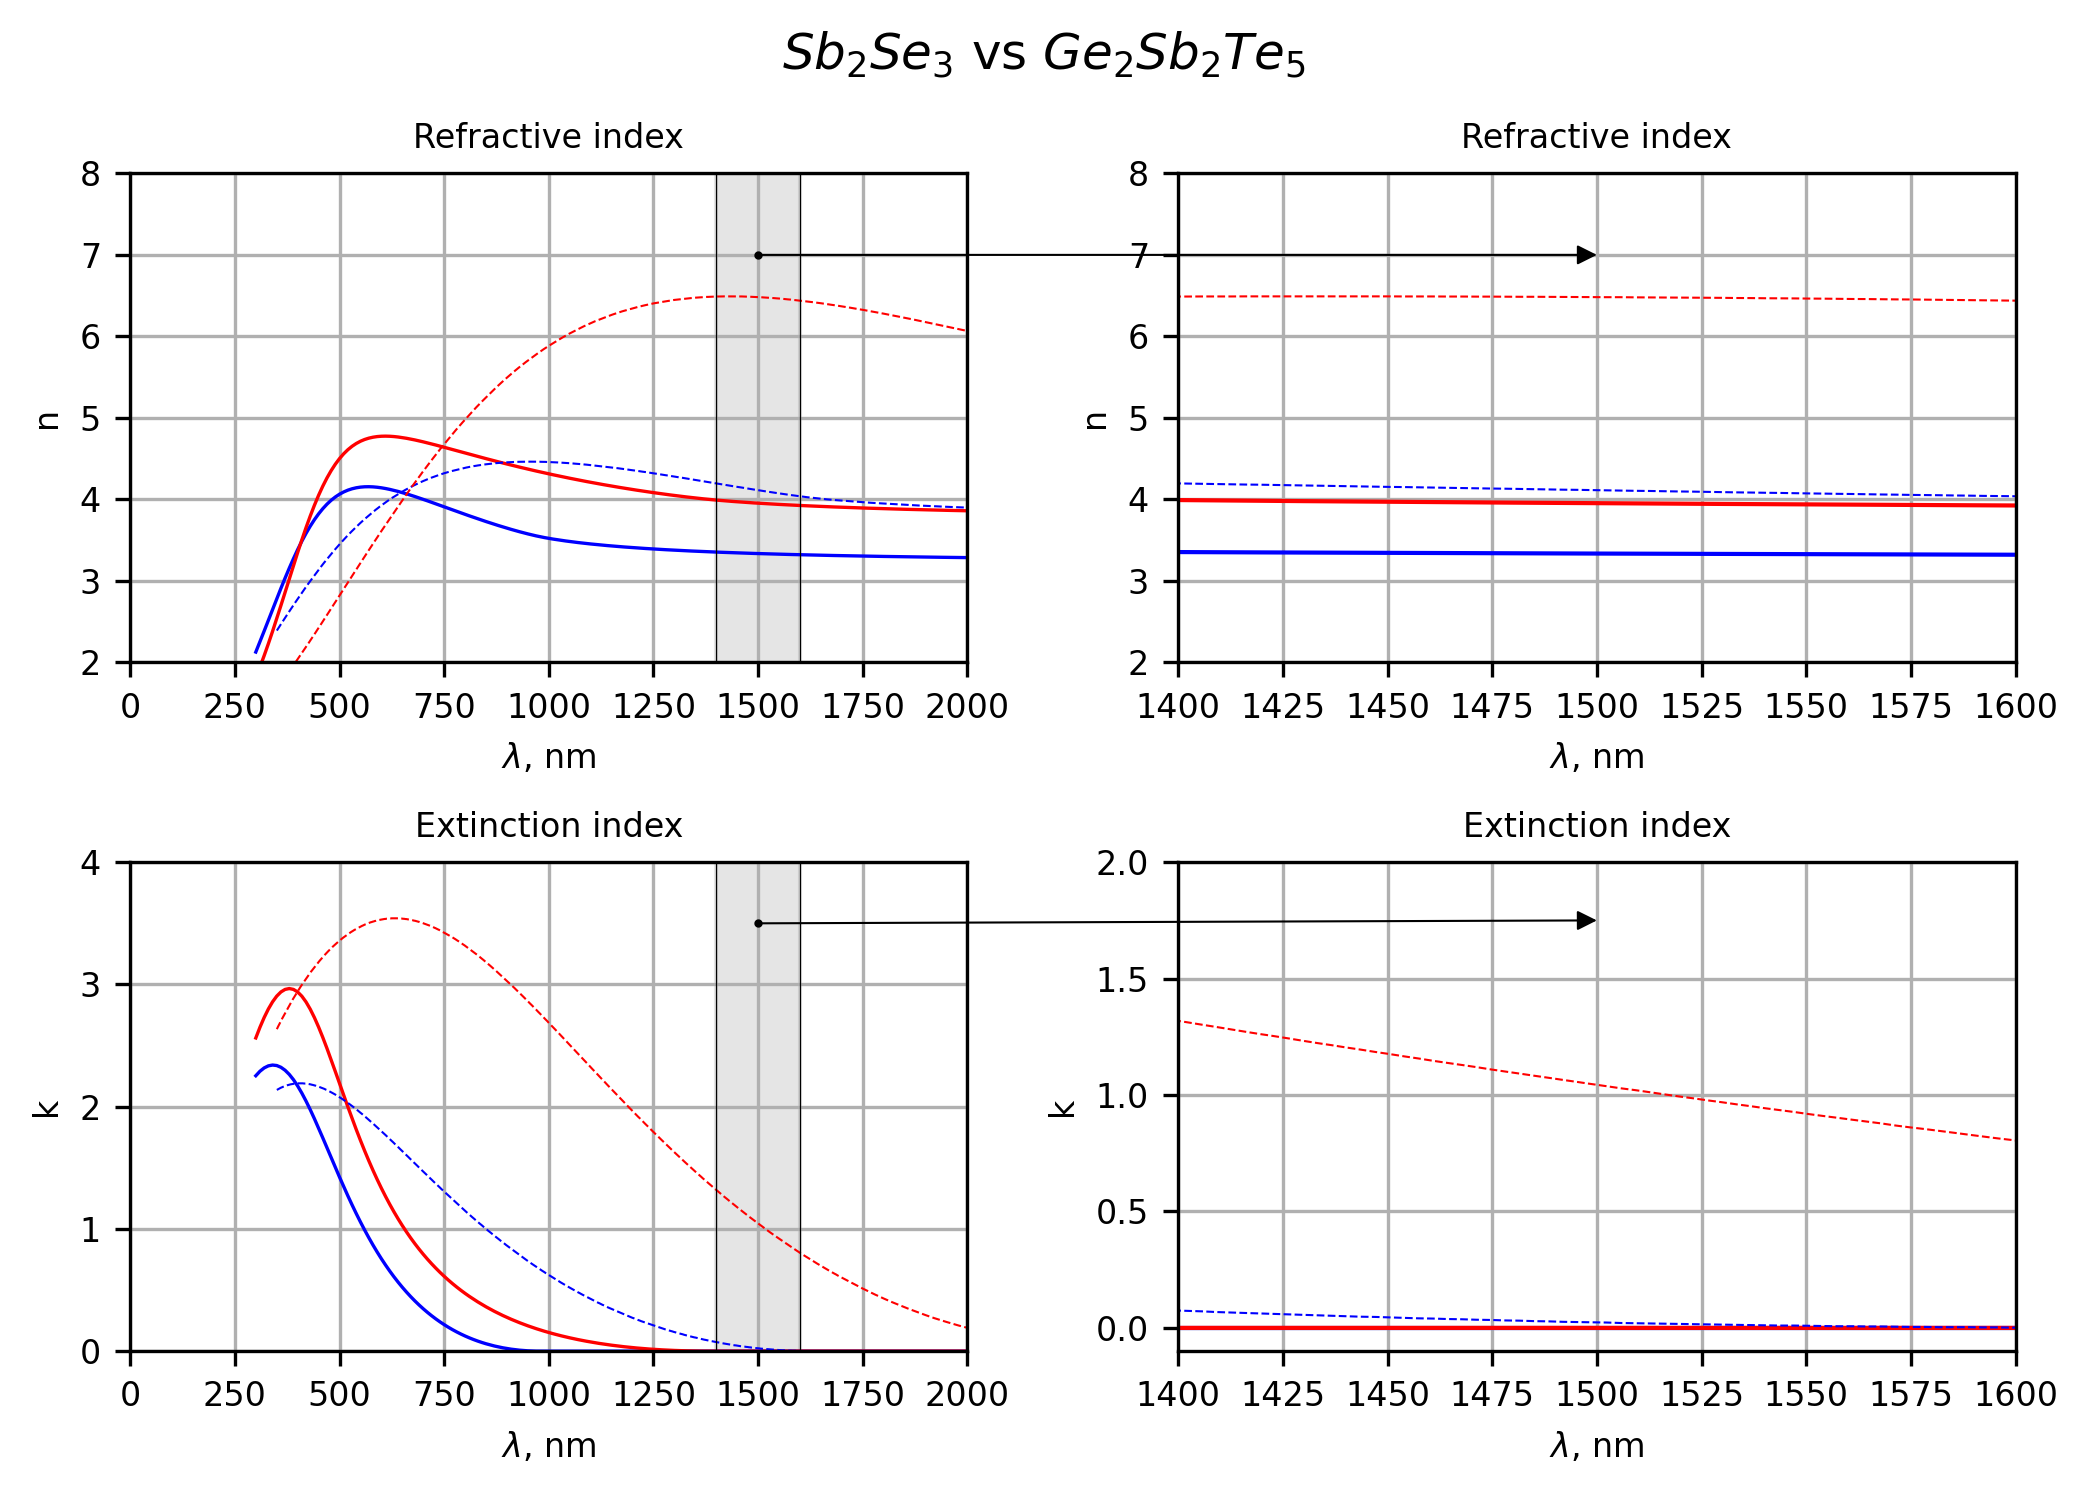

In [25]:
# --- Load materia
def g_theory(u, *, state: str):
    'Теоретическая передаточная функция'
    u = np.asarray(u, dtype=float)
    if state == "am":
        return u**2 + 0j
    if state == "cr":
        return 1j * u
    raise ValueError(f"unknown state={state!r}")

# модуль и фаза функции + нормировка
def amp_phase_from_g(u, *, state: str, D: float):
    'Модуль и фаза теоретической передаточной функции + нормировка'
    _ = D
    u = np.asarray(u, dtype=float)
    g = g_theory(u, state=state)
    amp = np.abs(g)
    gmax = np.amax(amp)
    if gmax > 0:
        amp = amp / gmax
    phase = np.angle(g)
    return amp, phase

def pixel_edges(D: float, Npix: int) -> np.ndarray:
    # Npix=11 -> 12 границ: [-5.5L, ..., +5.5L]
    L = D / Npix
    half = Npix / 2.0
    return np.linspace(-half * L, +half * L, Npix + 1)

def pixel_centers(D: float, Npix: int) -> np.ndarray:
    # центры: [-5L, -4L, ..., 0, ..., +5L]
    L = D / Npix
    return (np.arange(Npix) - (Npix // 2)) * L


def f_step(x, x1, y1):
    """
    Ступенчатая функция по границам интервалов.

    Пусть `x1` — массив границ (edges) длины n+1, а `y1` — значения на интервалах длины n:
      y1[i] действует на [x1[i], x1[i+1]) для i=0..n-1.
    Вне диапазона:
      x < x1[0]   -> y1[0]
      x >= x1[-1] -> y1[-1]
    """
    x1 = np.asarray(x1, dtype=float)
    y1 = np.asarray(y1)
    x  = np.asarray(x, dtype=float)
    if x1.ndim != 1 or y1.ndim != 1:
        raise ValueError("x1 и y1 должны быть одномерными массивами")
    if len(x1) < 2:
        raise ValueError("x1 должен содержать хотя бы 2 границы (n+1)")
    n = len(x1) - 1
    if len(y1) != n:
        raise ValueError("ожидается len(y1)=len(x1)-1 (значения на интервалах)")
    if not np.all(np.diff(x1) > 0):
        raise ValueError("x1 должен быть строго возрастающим массивом границ")

    idx = np.searchsorted(x1, x, side="right") - 1
    idx = np.clip(idx, 0, n - 1)
    return y1[idx]

def T_phi_pix(u, v, state: str, D: float, Npix: int, f_step):
    _ = v
    edges = pixel_edges(D, Npix)
    centers = pixel_centers(D, Npix)
    amp_c, phi_c = amp_phase_from_g(centers, state=state, D=D)  # теоретические в центрах
    Tpix = f_step(u, edges, amp_c)
    phipix = f_step(u, edges, phi_c)
    return Tpix, phipix
materials = load_materials(CFG, base_dir=CFG["data_dir"])

m_nk = MaterialsNK(
    sb2se3_am=materials.sb2se3_am,
    sb2se3_cr=materials.sb2se3_cr,
    gst_am=materials.gst_am,
    gst_cr=materials.gst_cr,
)

# --- Plot 1: materials n/k with zoom (from 3rd art, block 1-100) ---
figsize, dpi = get_plot_size(CFG, "materials_nk_zoom", default_figsize=(7.0, 5.0), default_dpi=300)

out_path = run.plots / "materials_nk_zoom.png"
fig = plot_materials_nk_zoom(m_nk, out_path=out_path, figsize=figsize, dpi=dpi)
out_path

2026-03-12 12:10:44,242 | INFO | loading surrogates from outputs/PCM_bagel_2025/models


PosixPath('outputs/PCM_bagel_2025/plots/data_pred_2x2.png')

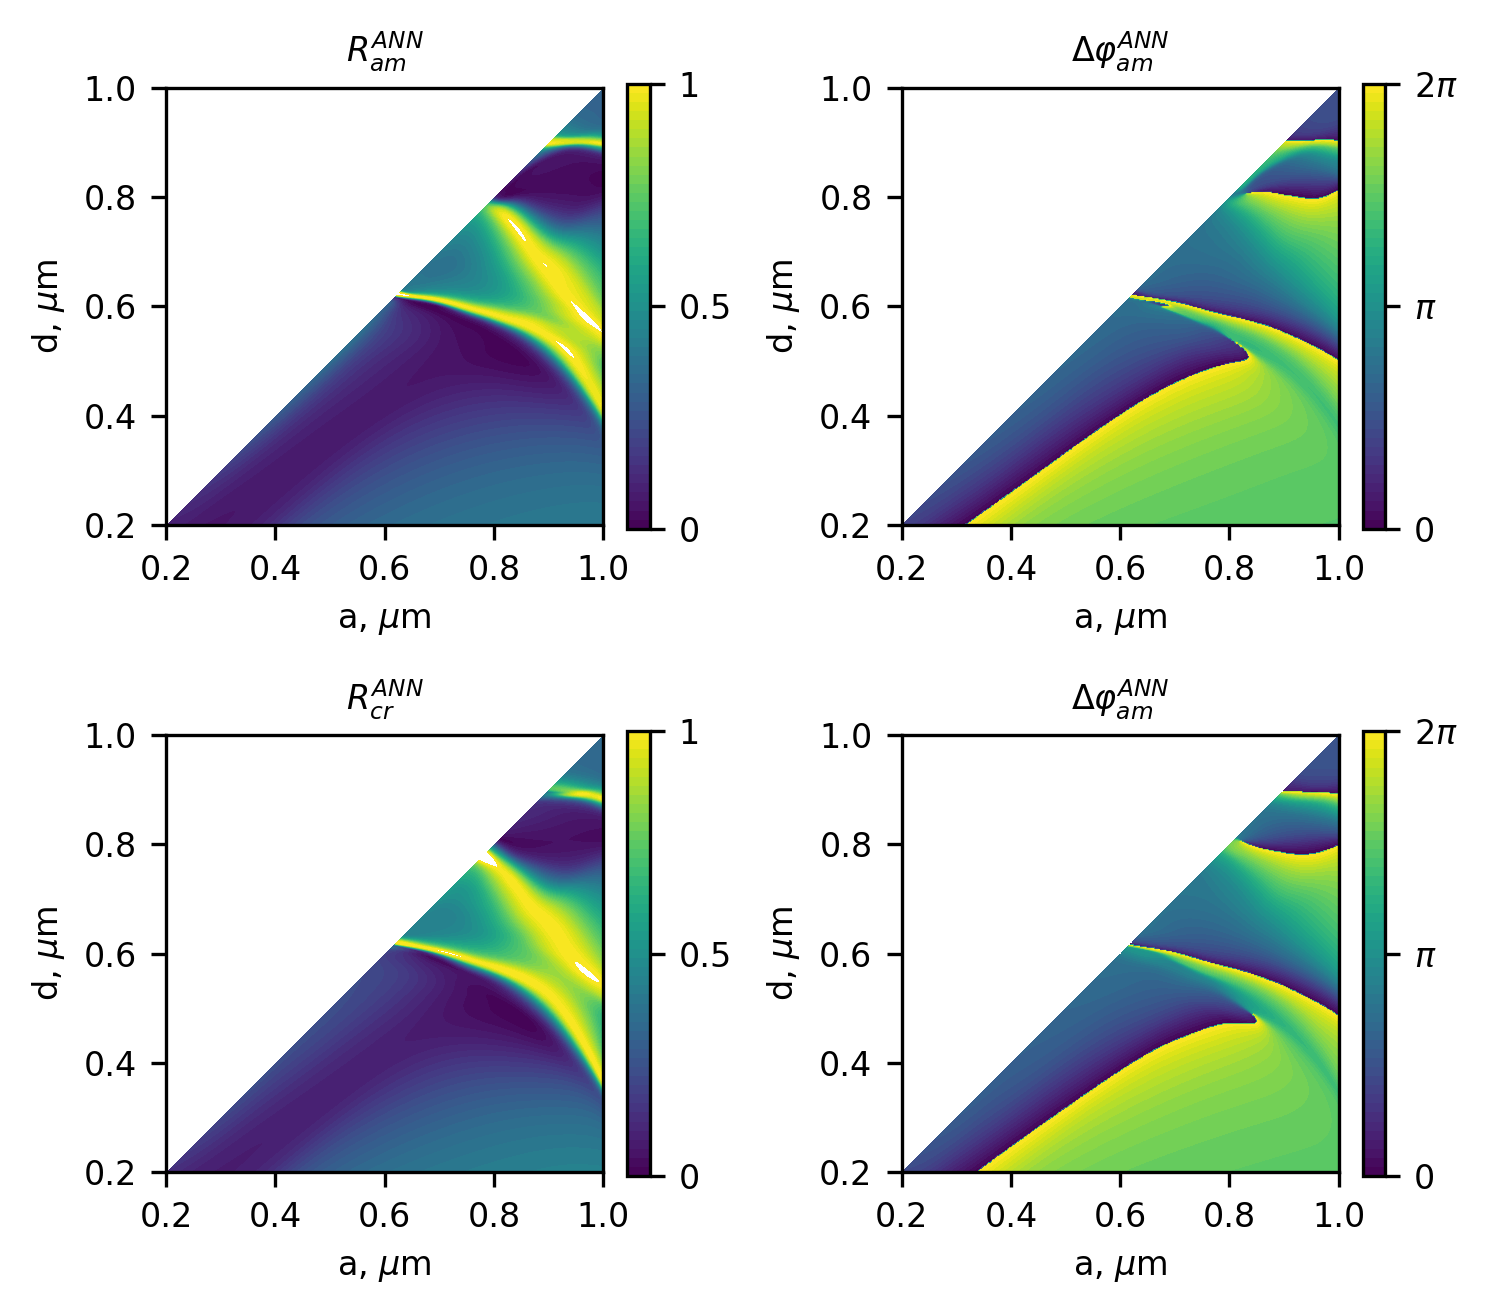

In [26]:
# --- Load / train surrogates (same logic as main_clean) ---
from pcm_pix.nn_surrogate import Net, get_device, load_legacy_surrogates, train_or_load_surrogates
from pcm_pix.features import load_mesh_tables, make_nn_dataset

# keep legacy unpickle working (torch.load(model) may reference __main__.Net)
Net

# device auto-detect
if CFG.get("device", "cpu") == "auto":
    CFG["device"] = get_device()

# build dataset only if we need to train new surrogates
mesh_tables = load_mesh_tables(CFG, base_dir=CFG["data_dir"])
ds = make_nn_dataset(mesh_tables, wl=CFG.get("wl", 1.55e-6))

if CFG.get("surrogate_mode", "legacy") == "legacy":
    CFG["legacy_dir"] = CFG["data_dir"]
    sur0, sur1 = load_legacy_surrogates(CFG, device=CFG.get("device", "cpu"))
else:
    sur0, sur1 = train_or_load_surrogates(ds, run, CFG, force_train=False)

"surrogates_ok"

# --- Plot 2: data_pred maps 2×2 (from 3rd art, block 1-67) ---
from pcm_pix.plots.pred_grid import PredGridCfg, make_data_pred_grid
from pcm_pix.plots.maps import plot_data_pred_2x2

# grid definition (as in old notebook: a,d in [0.2..1.0] μm, b fixed)
grid_cfg = PredGridCfg(
    a_min_m=0.2e-6,
    a_max_m=1.0e-6,
    d_min_m=0.2e-6,
    d_max_m=1.0e-6,
    b_value_m=0.0,
    n=int(CFG.get("plots_pred_grid_n", 400)),
    filter_a_gt_d=True,
)

data_pred = make_data_pred_grid(sur0, sur1, grid_cfg)

figsize, dpi = get_plot_size(CFG, "data_pred_2x2", default_figsize=(5.0, 5.0), default_dpi=300)

out_path = run.plots / "data_pred_2x2.png"
fig2 = plot_data_pred_2x2(data_pred, out_path=out_path, figsize=figsize, dpi=dpi)
out_path

PosixPath('outputs/PCM_bagel_2025/plots/data_pred_diffs_2x2.png')

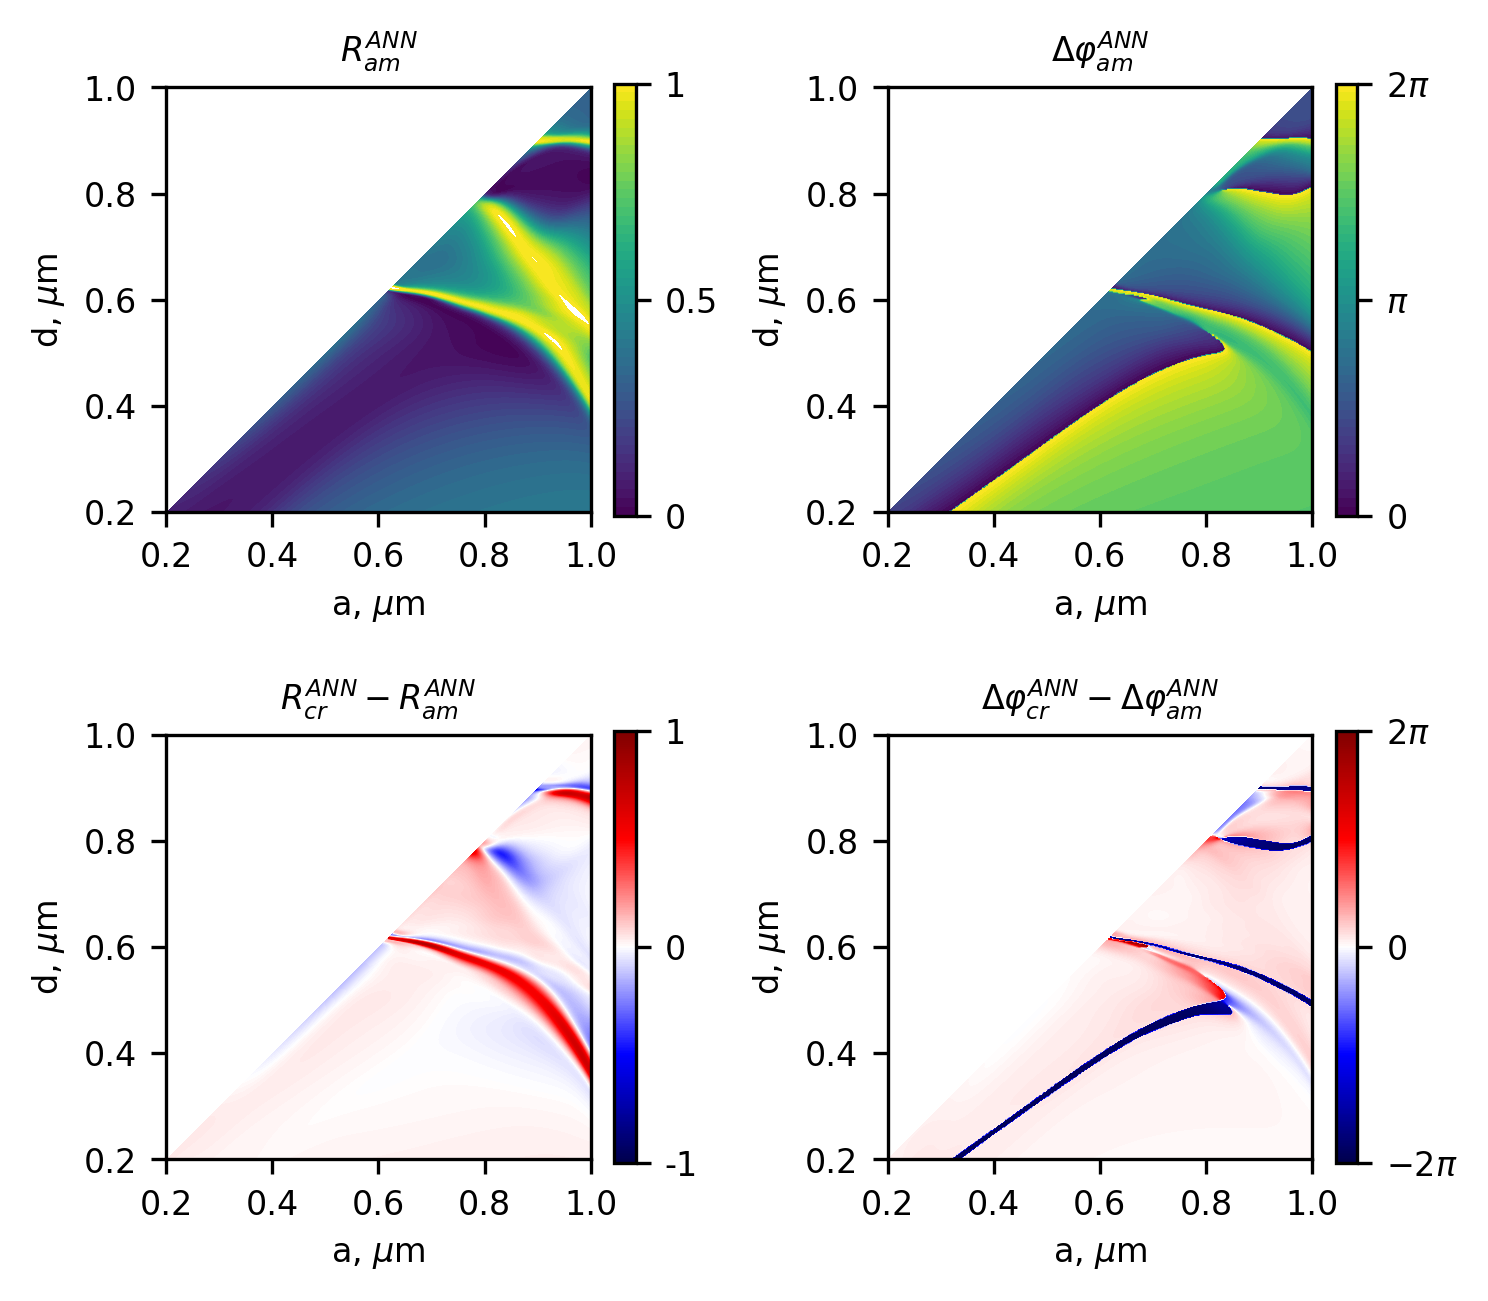

In [27]:
# --- Plot 3: data_pred diffs 2×2 (from 3rd art, block 1-73) ---
from pcm_pix.plots.maps import plot_data_pred_diffs_2x2

figsize, dpi = get_plot_size(CFG, "data_pred_diffs_2x2", default_figsize=(5.0, 5.0), default_dpi=300)

out_path = run.plots / "data_pred_diffs_2x2.png"
fig3 = plot_data_pred_diffs_2x2(data_pred, out_path=out_path, figsize=figsize, dpi=dpi)
out_path

PosixPath('outputs/PCM_bagel_2025/plots/true_vs_pred_2x4.png')

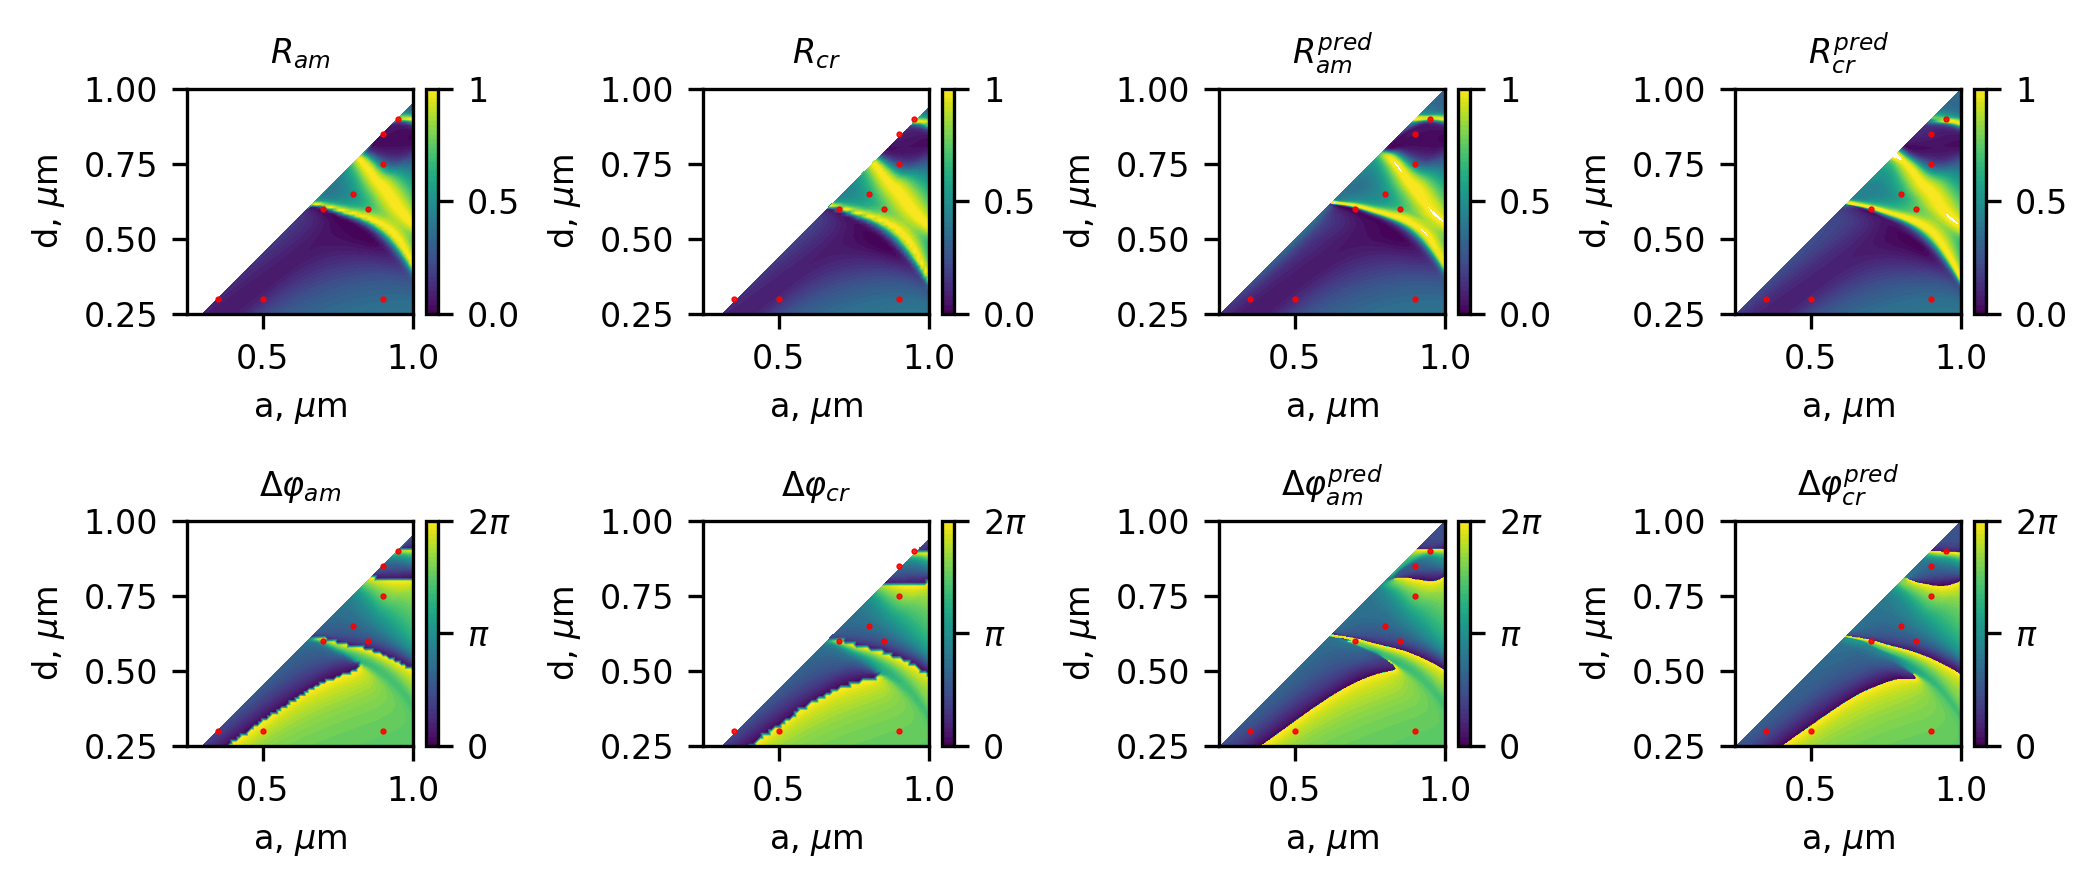

In [28]:
# --- Plot 4: true vs pred 2×4 (from 3rd art, block 1-170) ---
from pcm_pix.plots.maps import plot_true_vs_pred_2x4

# In old notebook: wl fixed and b_fix=0
wl_fix = float(CFG.get("wl", 1.55e-6))
b_fix = float(CFG.get("plots_b_fix_m", 0.0))

figsize, dpi = get_plot_size(CFG, "true_vs_pred_2x4", default_figsize=(7.0, 3.0), default_dpi=300)

out_path = run.plots / "true_vs_pred_2x4.png"
fig4 = plot_true_vs_pred_2x4(
    ds.df,
    data_pred,
    wl=wl_fix,
    b_fix=b_fix,
    out_path=out_path,
    figsize=figsize,
    dpi=dpi,
    xlim_c=(0.25, 1.0),
)
out_path

PosixPath('outputs/PCM_bagel_2025/plots/multipole_fields.png')

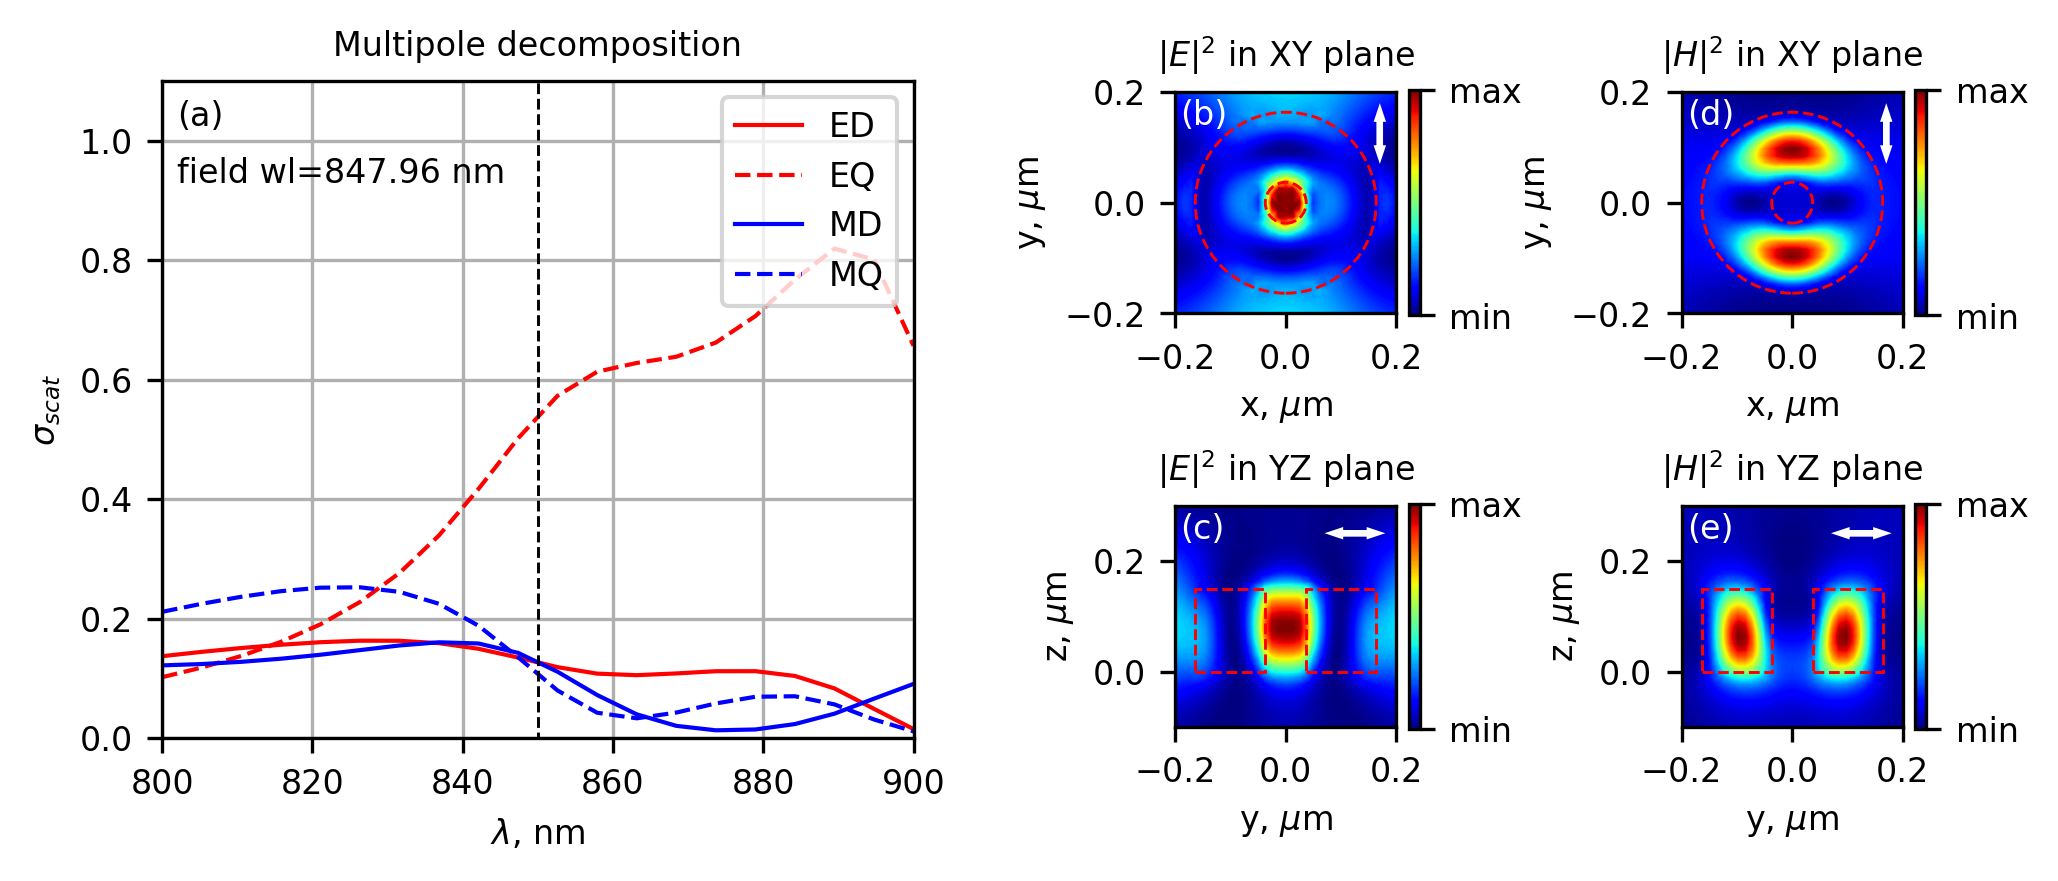

In [29]:
# --- Plot 5: multipole decomposition + fields (from 3rd art, block 1-158) ---
# Требует внешних файлов EQ/EQMQ и EHforV.
from pcm_pix.plots.multipole_fields import (
    load_multipole_table,
    load_field_table,
    plot_multipole_and_fields,
)

# Пути к файлам (подставь свои). Рекомендация: положить их в data/ и прописать относительные пути.
MULTI_PATH = Path(CFG["data_dir"]) / "EQ.txt"
FIELD_PATH = Path(CFG["data_dir"]) / "EQEHforV.txt"

if not MULTI_PATH.exists() or not FIELD_PATH.exists():
    raise FileNotFoundError(f"Need files: {MULTI_PATH} and {FIELD_PATH}")

multi = load_multipole_table(MULTI_PATH)
field = load_field_table(FIELD_PATH)

figsize, dpi = get_plot_size(CFG, "multipole_fields", default_figsize=(6.9, 3.0), default_dpi=300)

out_path = run.plots / "multipole_fields.png"
# Важно для 1-в-1: в старом ноутбуке поле отбиралось по одной длине волны (обычно ближайшей к 850 nm)
fig5 = plot_multipole_and_fields(
    multi,
    field,
    field_wl_target_nm=float(CFG.get("plots_field_wl_nm", 850.0)),
    out_path=out_path,
    figsize=figsize,
    dpi=dpi,
)
out_path

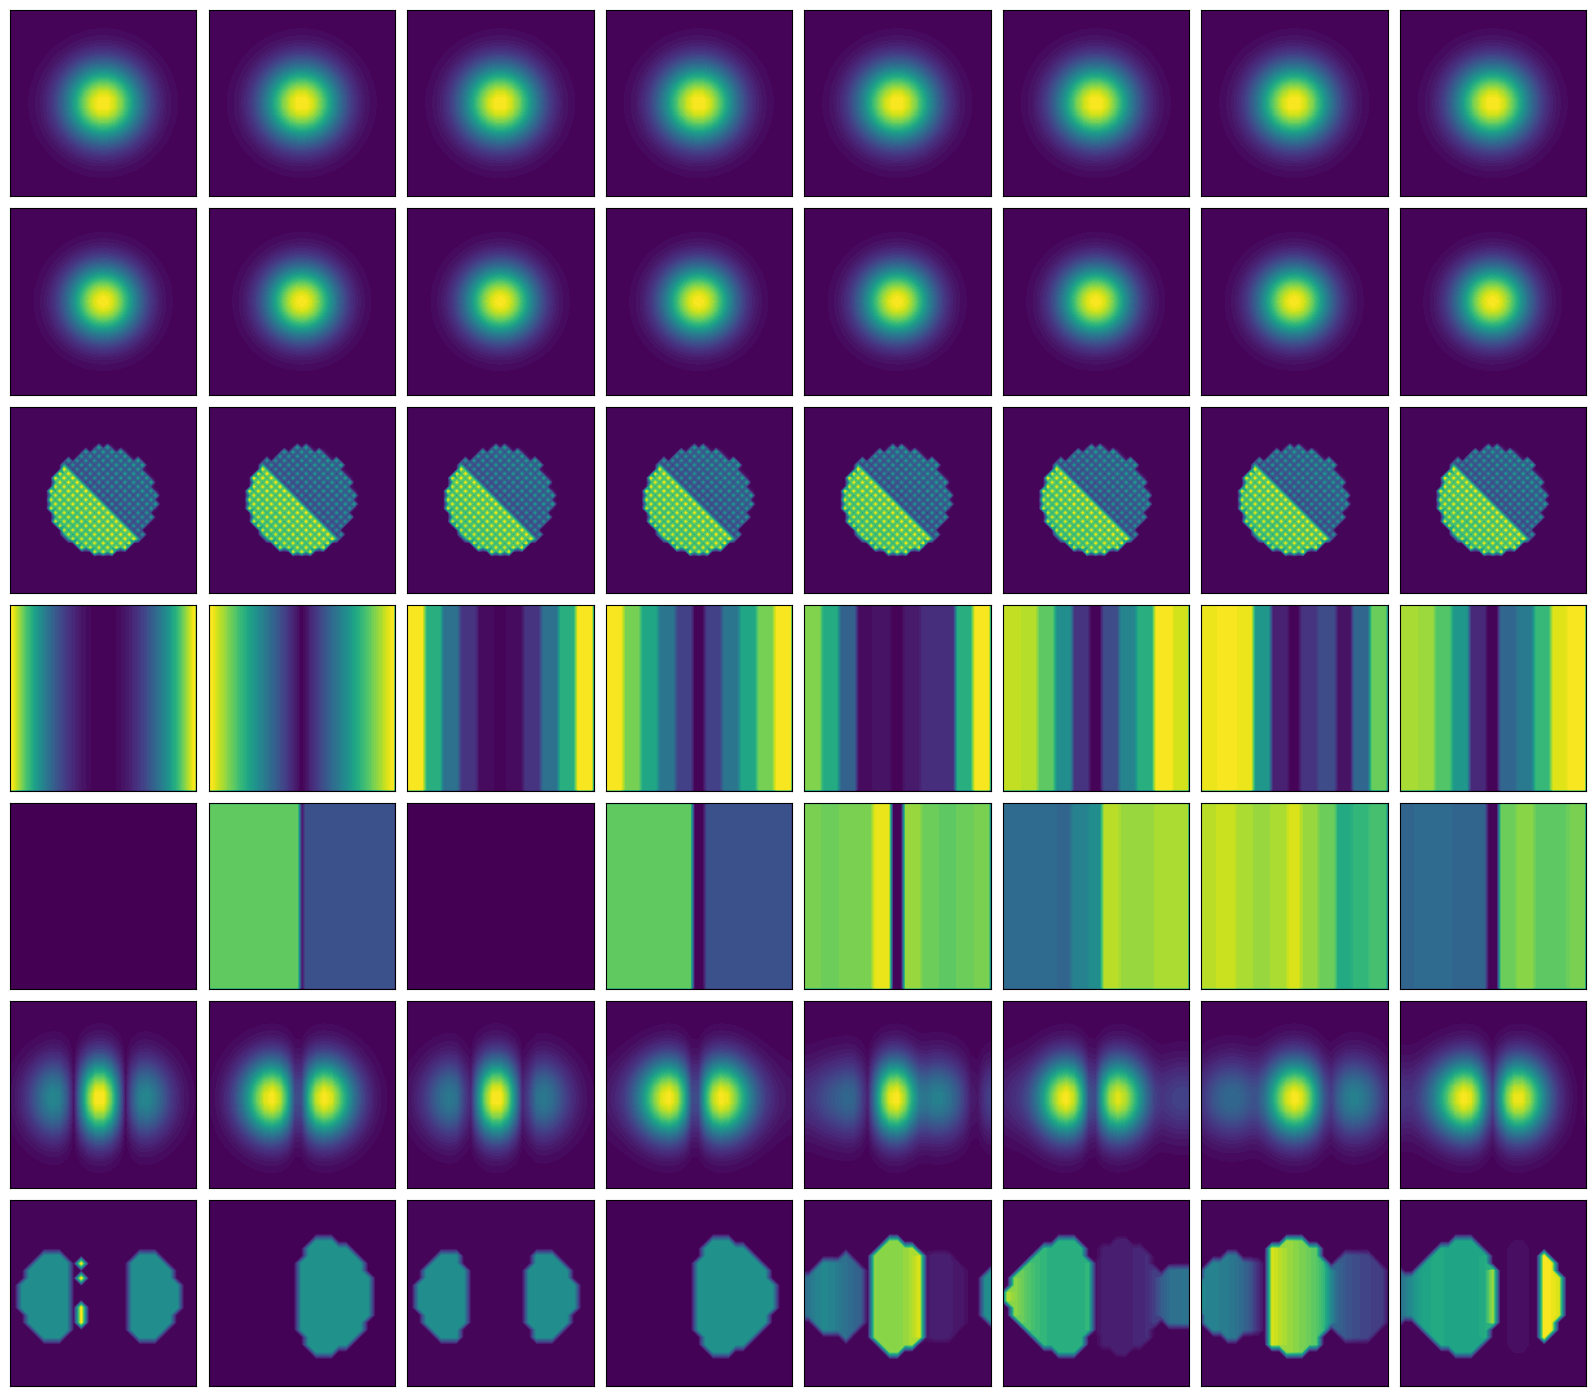

In [30]:
import importlib
import pcm_pix.plots.deriv_stack as ds

importlib.reload(ds)  # перезагрузить модуль с диска

from pcm_pix.plots.deriv_stack import plot_transfer_conv_stack
fig = plot_transfer_conv_stack(
    N=128,
    width=50e-3,
    f_gl=125e-3,
    wl_gl=1550e-9,
    S_gl=165e-6,
    s=2.0e-3,
    Npix=11,
    xy_display=5e-3,
    uv_display=165e-6/2,
    figsize=(16, 14),
    dpi=None,
)

PosixPath('outputs/PCM_bagel_2025/plots/theory_pix_lum_overlay_2x2.png')

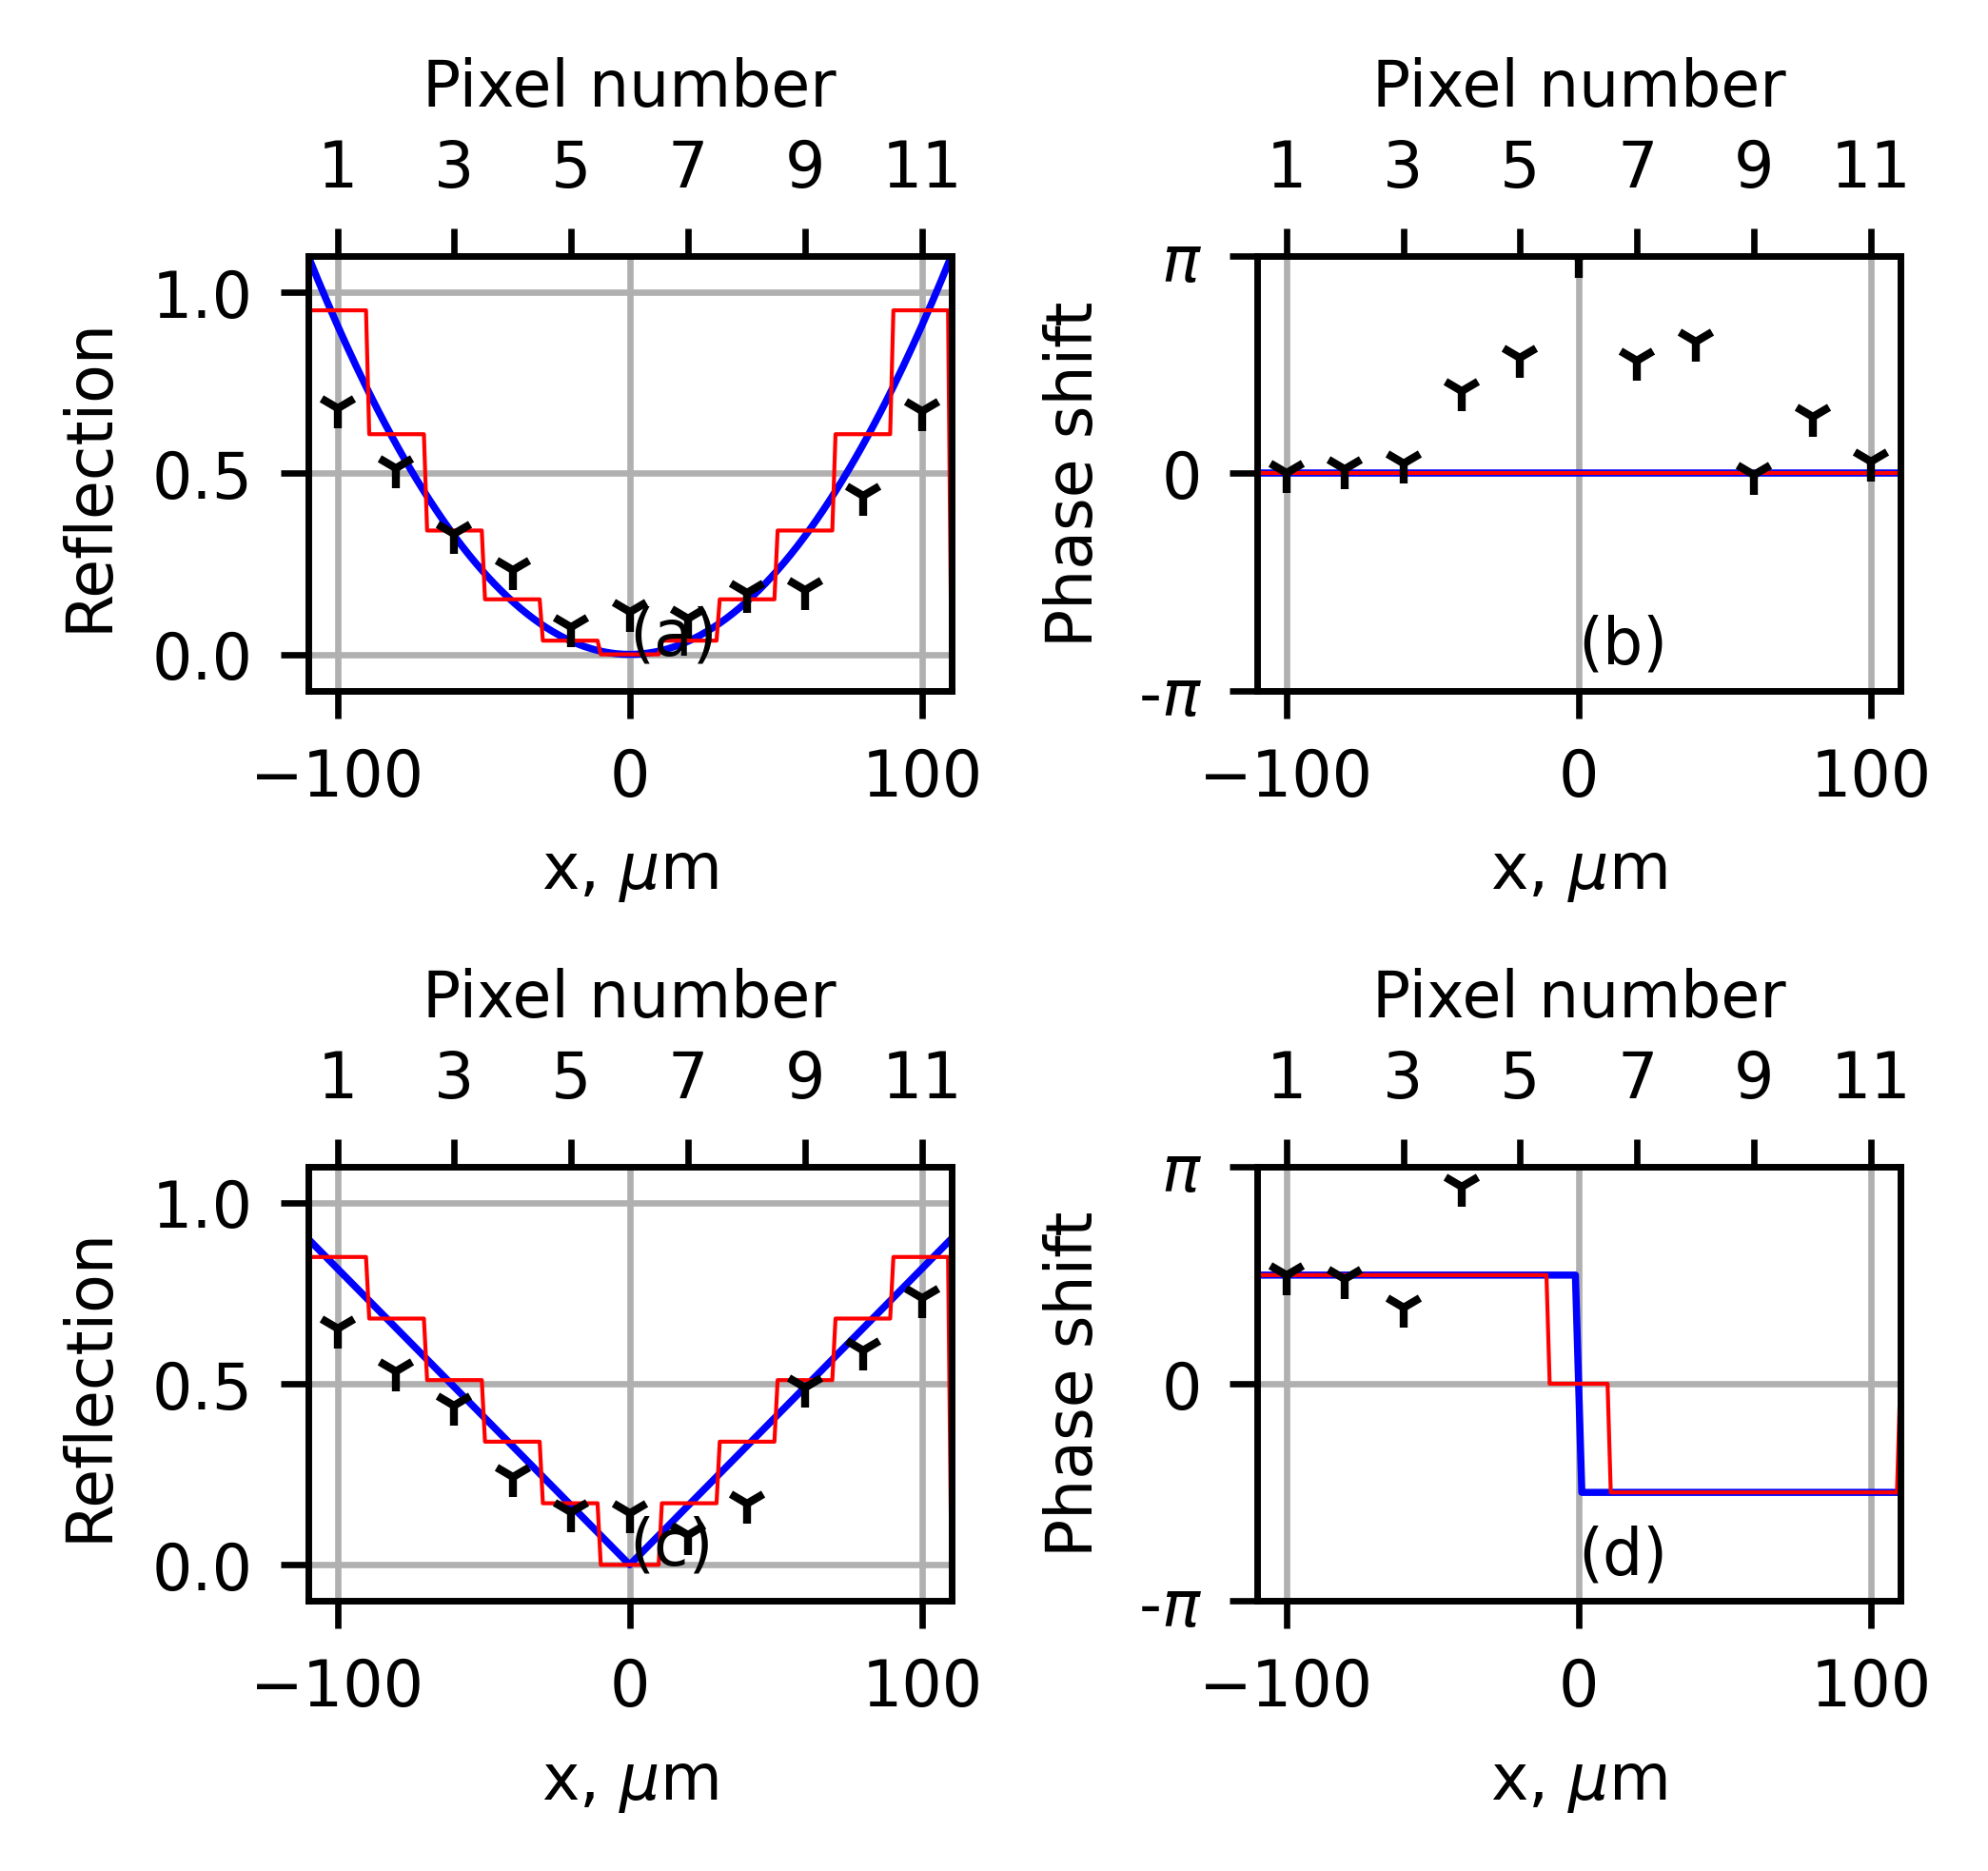

In [51]:
# --- Plot 6: theory vs pixel + lum overlays (from 3rd art, block ~1-116 for this figure) ---
# Важно: pos берём из пресета, указанного в CFG (как в main_clean.ipynb).
from pcm_pix.optimize import load_solution
from pcm_pix.plots.theory_pix_lum import plot_theory_pix_lum_overlay_2x2, TheoryPixLumLayers



preset_name = CFG.get("preset_name", None)
preset_name = "pos_2026_03_03_example"
#preset_name = "pos_server_2026_03_04_night"
preset_name = "pos_test_2026_03_12"


if not preset_name:
    raise KeyError("CFG['preset_naкme'] is required to load pos preset")

sol_path = "./data/preset/" + f"{preset_name}.json"

pos, _cost, _meta = load_solution(sol_path)

# Управление слоями (overlays): можно отключать/включать отдельные наложения.
# Формат в CFG (рекоменд.):
CFG.setdefault("plots", {})
CFG["plots"].setdefault("theory_pix_lum_overlay", {})
CFG["plots"]["theory_pix_lum_overlay"]["layers"] = {
    "show_theory": True,
    "show_pix": True,
    "show_lum_ann": True,
    "show_lum_exp": False,
    "show_lum_cones": False,
    "show_panel_labels": True,
    "show_grid": True,
}

layer_dict = CFG["plots"]["theory_pix_lum_overlay"]["layers"]
layers = TheoryPixLumLayers(**layer_dict)

figsize, dpi = get_plot_size(CFG, "theory_pix_lum_overlay", default_figsize=(3.5, 3.3), default_dpi=600)

out_path = run.plots / "theory_pix_lum_overlay_2x2.png"
fig6 = plot_theory_pix_lum_overlay_2x2(
    pos=pos,
    sur0=sur0,
    sur1=sur1,
    cfg=CFG,
    layers=layers,
    figsize=figsize,
    dpi=dpi,
    out_path=out_path,
)
out_path

Run(root=PosixPath('outputs/PCM_bagel_2025'), logs=PosixPath('outputs/PCM_bagel_2025/logs'), plots=PosixPath('outputs/PCM_bagel_2025/plots'), models=PosixPath('outputs/PCM_bagel_2025/models'), results=PosixPath('outputs/PCM_bagel_2025/results'), gds=PosixPath('outputs/PCM_bagel_2025/gds'), logger=<Logger pcm_run:PCM_bagel_2025 (INFO)>)

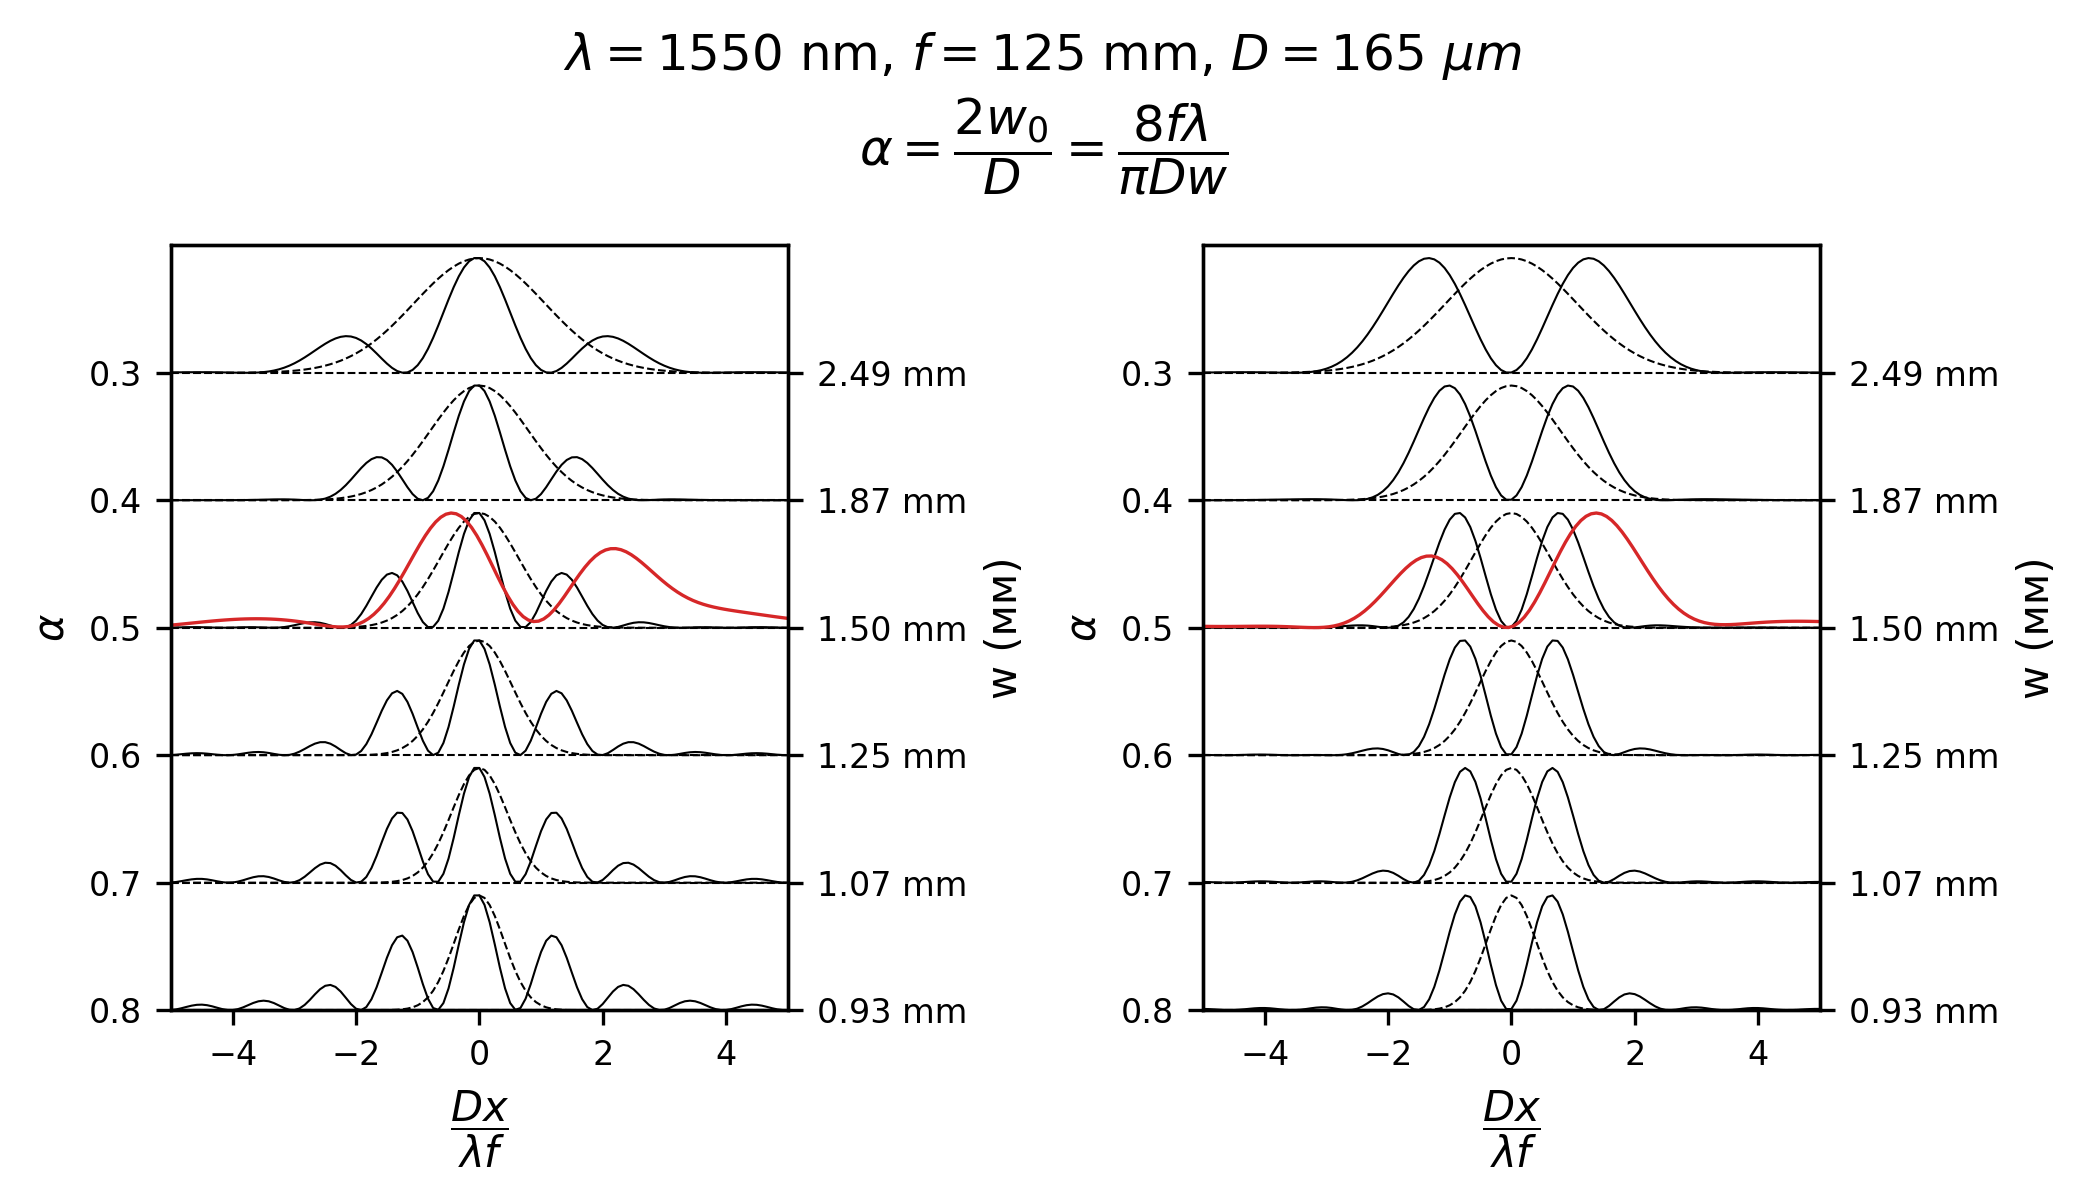

In [40]:
import importlib
import pcm_pix.plots.deriv_stack as ds
import numpy as np
importlib.reload(ds)
from pcm_pix.plots.deriv_stack import plot_output_slices_1x2

alpha_list = np.array([0.8, 0.7, 0.6, 0.5, 0.4, 0.3])
exp_files = {
    (0.5, "cr"): "./data/Gauss_165_cr_alpha0.5.txt",
    (0.5, "am"): "./data/Gauss_165_am_alpha0.5.txt",
}


fig = plot_output_slices_1x2(
    N=512,
    width=50e-3,
    f_gl=125e-3,
    wl_gl=1550e-9,
    S_gl=165e-6,
    Npix=11,
    xy_display=5.0,
    #mode="dataset_2",
    mode="ideal_pixel",
    #mode="theory",
    alpha_list=alpha_list,
    exp_files=exp_files,
)